### **1.Consumo di alcol per paese** 
Esegui un’**analisi esplorativa** focalizzata sul **consumo di alcol**.  
Analizza i seguenti aspetti:
1. Visualizza i primi 10 paesi ordinati per total_litres_of_pure_alcohol (dal più alto)

2. Calcola la media del consumo di birra, vino, e distillati

3. Crea una nuova colonna alcohol_index che sia: `(beer_servings + wine_servings + spirit_servings) / 3`

4. Trova il paese con il valore massimo di alcohol_index

5. Filtra solo i paesi che consumano più di 100 birre all’anno

6. Crea un bar chart dei 10 paesi con più consumo totale (total_litres_of_pure_alcohol)

7. Crea un line plot con wine_servings ordinato per paese (usa sort_values)

In [3]:
import pandas as pd
df = pd.read_csv("drinks.csv")
df

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [4]:
#1
top_10_country_by_total_alcohol = df.sort_values(by="total_litres_of_pure_alcohol", ascending=False)[['country', 'total_litres_of_pure_alcohol']].head(10)
print("primi 10 paesi ordinati per total_litres_of_pure_alcohol:")
print(top_10_country_by_total_alcohol)

#2
medie_birra = df['beer_servings'].mean()
medie_vino = df['wine_servings'].mean()
medie_distillati = df['spirit_servings'].mean()
print("medie birra:", round(medie_birra, 3))
print("medie vino:", round(medie_vino, 3))
print("medie distillati:", round(medie_distillati, 3))

#3
df['alcohol_index'] = df[['beer_servings', 'wine_servings', 'spirit_servings']].mean(axis=1)

#4
print(df.loc[df['alcohol_index'].idxmax(),'country'])

#5
print(df.loc[df['beer_servings'] > 100, 'country'])

primi 10 paesi ordinati per total_litres_of_pure_alcohol:
                country  total_litres_of_pure_alcohol
15              Belarus                          14.4
98            Lithuania                          12.9
3               Andorra                          12.4
68              Grenada                          11.9
61               France                          11.8
45       Czech Republic                          11.8
141  Russian Federation                          11.5
99           Luxembourg                          11.4
155            Slovakia                          11.4
81              Ireland                          11.4
medie birra: 106.161
medie vino: 49.451
medie distillati: 80.995
Andorra
3                Andorra
4                 Angola
5      Antigua & Barbuda
6              Argentina
8              Australia
             ...        
182       United Kingdom
184                  USA
185              Uruguay
188            Venezuela
189              Vietnam


<Axes: xlabel='country'>

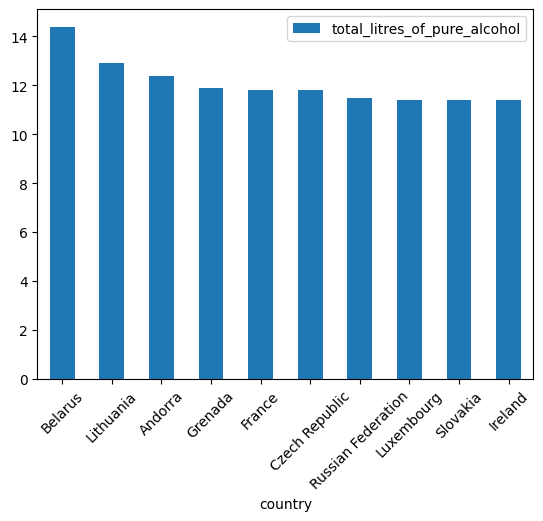

In [27]:
#6
top_10_country_by_total_alcohol.plot.bar(x="country", y="total_litres_of_pure_alcohol", rot=45)


<Axes: xlabel='country'>

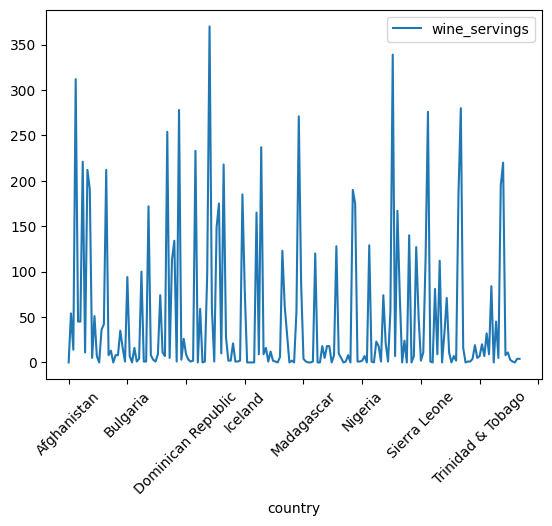

In [29]:
#7
df.sort_values(by='country').plot.line(x="country", y="wine_servings", rot=45)

### **2.Analisi offerte di lavoro** 

Esegui un’**analisi esplorativa** focalizzata sui **lavori nel campo dei dati in ciascun paese**.  
Analizza i seguenti aspetti per ogni paese:

* Lo **stipendio medio annuale** (`salary_year_avg`)
* Il **numero totale di offerte di lavoro** (job count)
* L’intervallo degli stipendi: **valore minimo e massimo** (`min` / `max`)

Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.

In [2]:
import pandas as pd
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])

/Users/lorenzomarinolli/universita/programmazione_laboratorio/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
(
    df[['search_location', 'salary_year_avg', 'job_title']]
    .dropna(subset="salary_year_avg")
    .groupby(by="search_location")
    .agg({
        "salary_year_avg" : ["mean", "min", "max"],
        "job_title" : "count"})
)

salary_year_avg                    job_title
                           mean      min       max     count
search_location                                             
Albania            79472.500000  43200.0  157500.0         5
Algeria            44550.000000  44100.0   45000.0         2
Argentina         105212.343750  45000.0  222000.0        32
Armenia            78757.000000  45000.0  128682.0         6
Australia         118987.574324  20000.0  257500.0        74
...                         ...      ...       ...       ...
Uruguay            69333.333333  50000.0  100500.0         3
Uzbekistan         30750.000000  30750.0   30750.0         1
Vietnam            90927.236364  28000.0  200000.0        55
Zambia             90670.000000  90670.0   90670.0         1
Zimbabwe           67056.666667  47500.0   90670.0         3

[113 rows x 4 columns]

In [14]:
df.columns

Index(['job_title_short', 'job_title', 'job_location', 'job_via',
       'job_schedule_type', 'job_work_from_home', 'search_location',
       'job_posted_date', 'job_no_degree_mention', 'job_health_insurance',
       'job_country', 'salary_rate', 'salary_year_avg', 'salary_hour_avg',
       'company_name', 'job_skills', 'job_type_skills'],
      dtype='str')

<Axes: title={'center': 'stipendio medio per lavoro'}, xlabel='stipendio medio', ylabel='titolo del lavoro'>

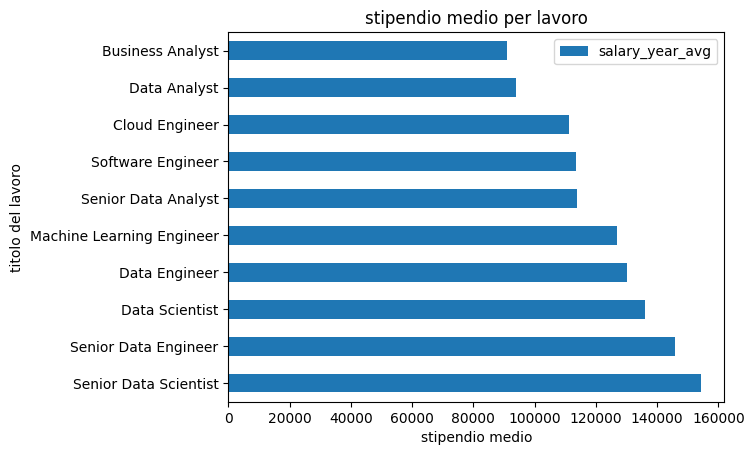

In [ ]:
#Rappresenta graficamente lo stipendio medio (`salary_year_avg`) per `job_title_short` usando un grafico a barre orizzontali. 
# Ordina i dati dallo stipendio più alto al più basso. Includi un titolo e le etichette per gli assi x e y.
#.plot.barh(x="job_title_short", y="salary_year_avg", title="stipendio medio per lavoro")
(
    df.groupby(by='job_title_short')
    .agg({"salary_year_avg" : "mean"})
    .sort_values(by="salary_year_avg")
    .plot.barh(y="salary_year_avg", title="stipendio medio per lavoro", xlabel="stipendio medio", ylabel="titolo del lavoro")
)

### **3. Analisi vendite (dataset tips)**

Esegui un’**analisi esplorativa** focalizzata sulle **vendite giornaliere**.  
Analizza i seguenti aspetti per ogni giorno (`day`):

* Il **conto medio** (`total_bill`)
* Il **numero totale di osservazioni** (conteggio delle righe)
* Il **valore minimo e massimo** del conto (`total_bill` → `min` / `max`)

* Crea una nuova colonna `conto_per_persona` che sia:  
  `total_bill / size`

* Trova il giorno con il **conto medio più alto**

Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
Ordina i dati dal valore più alto al più basso.  
Aggiungi titolo ed etichette agli assi.

In [34]:
url = "sales.csv"
df = pd.read_csv(url)

df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [ ]:
df_stats = (
    df.groupby(by="day")
    .agg({
        "total_bill" : ["min", "mean", "max"]
    })
)
numero_osservazioni = len(df_stats)
df['conto_per_persona'] = round(df['total_bill'] / df['size'], 3)
print(df_stats)
print("numero osservazioni:", numero_osservazioni)
print(df)
print("il giorno con il conto medio più alto è",df_stats['total_bill']['mean'].idxmax())


     total_bill                  
            min       mean    max
day                              
Fri        5.75  17.151579  40.17
Sat        3.07  20.441379  50.81
Sun        7.25  21.410000  48.17
Thur       7.51  17.682742  43.11
numero osservazioni: 4
     total_bill   tip     sex smoker   day    time  size  conto_per_persona
0         16.99  1.01  Female     No   Sun  Dinner     2              8.495
1         10.34  1.66    Male     No   Sun  Dinner     3              3.447
2         21.01  3.50    Male     No   Sun  Dinner     3              7.003
3         23.68  3.31    Male     No   Sun  Dinner     2             11.840
4         24.59  3.61  Female     No   Sun  Dinner     4              6.148
..          ...   ...     ...    ...   ...     ...   ...                ...
239       29.03  5.92    Male     No   Sat  Dinner     3              9.677
240       27.18  2.00  Female    Yes   Sat  Dinner     2             13.590
241       22.67  2.00    Male    Yes   Sat  Dinner     

<Axes: title={'center': 'Conto medio per giorno'}, xlabel='giorno', ylabel='media'>

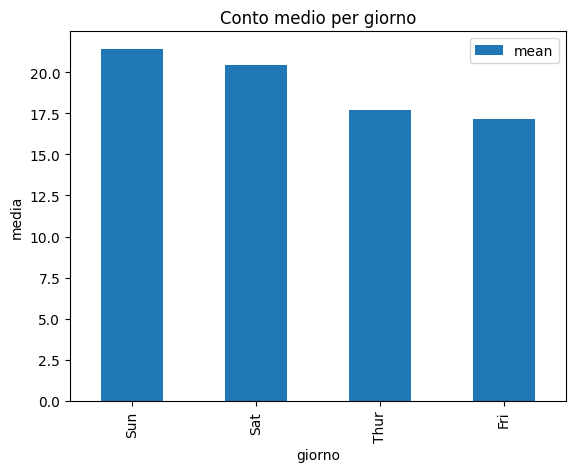

In [59]:
# Rappresenta graficamente il **conto medio (`total_bill`) per giorno** usando un **grafico a barre**.  
# Ordina i dati dal valore più alto al più basso.  
# Aggiungi titolo ed etichette agli assi.

df_stats['total_bill'].sort_values(by="mean", ascending=False).plot.bar(y="mean", title="Conto medio per giorno", xlabel="giorno", ylabel="media")